In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import bibtexparser
import numpy as np
import seaborn as sns
import re

## Lecture des données brutes

In [2]:
df = pd.read_csv('extraction_covidence.csv')
df

,Covidence #,Study ID,Title,Reviewer Name,Objectifs de l'étude,Langage de requête,Langage d'arrimage,Méthode d'opérationnalisation,Utilisation du modèle commun,Couverture des exigences:,...,E03 – Documentation des arrimages Détail,E04 – Support de différents SGBD Oui / Non / NA / ?,E04 – Support de différents SGBD Détail,E05 – Accessibilité du code source Oui / Non / NA / ?,E05 – Accessibilité du code source Détail,E06 – Support des types de données utilisés dans le modèle de connaissance Oui / Non / NA / ?,E06 – Support des types de données utilisés dans le modèle de connaissance Détail,E07 – Documentation d’un procédé d’individuation Oui / Non / NA / ?,E07 – Documentation d’un procédé d’individuation Détail,Court résumé
0,1080,Chen 2005,DartGrid III: A semantic grid toolkit for data...,Consensus,Permettre l'accès aux données de sources hétér...,SPARQL,Relationnel,Médiation,Centré sur le modèle commun,NaN,...,NaN,?,NaN,Non,NaN,Non,NaN,Non,NaN,DartGrid propose de définir une ontologie de d...
1,849,Berardi 2015,R2BA: Rationalizing R2RML mapping by assertion,Consensus,Proposer une méthode d'arrimage R2RML qui sois...,SPARQL,DSL,Médiation,Centré sur la source,NaN,...,NaN,?,NaN,Non,NaN,Non,NaN,Non,NaN,La méthode proposée est divisée en trois parti...
2,625,Köhler 2003,SEMEDA: ontology based semantic integration of...,Consensus,Unifier des bases de données biologiques à l'a...,Other: Interface graphique,Relationnel,Alimentation,Centré sur le modèle commun,NaN,...,NaN,oui,NaN,non,NaN,non,NaN,non,NaN,L'article propose un modèle de description d'u...
3,609,Mate 2015,Ontology-based data integration between clinic...,Consensus,Permettre l'accès à des données médico-adminis...,Relationnel,Relationnel,Alimentation,Centré sur le modèle commun,NaN,...,NaN,non,NaN,non,NaN,oui,NaN,non,NaN,L'article propose une méthode pour permettre d...
4,524,Banhalmi 2013,Development of a Novel Semantic-based System I...,Consensus,Proposer une méthode de médiation basé sur les...,SPARQL,DSL,Médiation,Centré sur le modèle commun,NaN,...,NaN,Oui,NaN,Non,NaN,Oui,NaN,Non,NaN,La méthode propose de générer un arrimage Ques...
5,482,Sicilia 2017,Map-On: A web-based editor for visual ontology...,Consensus,Appuyer le processus de développement d'arrima...,SPARQL,R2RML,Médiation,Centré sur le modèle commun,NaN,...,NaN,oui,NaN,oui,NaN,non,NaN,non,NaN,L'article propose une interface graphique perm...
6,461,Asprino 2023,Knowledge Graph Construction with a<i>Façade<...,Consensus,Donner accès à la source en RDF avant de procé...,SPARQL,SPARQL,Alimentation,Centré sur le modèle commun,NaN,...,NaN,Non,NaN,Non,NaN,Oui,NaN,Non,NaN,L'article propose une méthode pour accéder à d...
7,413,Calvanese 2017,Ontop: answering SPARQL queries over relationa...,Consensus,Permettre l'accès aux données d'un SGBD à part...,SPARQL,R2RML,Médiation,Centré sur le modèle commun,NaN,...,NaN,Oui,NaN,Oui,NaN,Non,Conversion en chaîne de caractères,Non,NaN,Ontop est un système d'accès aux données basés...
8,327,Pankowski 2017,Exploring ontology-enhanced bibliography datab...,Consensus,L'article vise à permettre l'accès aux données...,Other: Interface graphique,DSL,Médiation,Centré sur le modèle commun,NaN,...,NaN,non,NaN,oui,NaN,non,NaN,non,NaN,L'arrimage entre l'ontologie de référence et l...
9,210,Jia 2012,SMap: Semantically mapping relational database...,Consensus,Exposer une base de données relationnelle à l'...,SPARQL,Relationnel,Alimentation,Centré sur le modèle commun,NaN,...,NaN,?,on indique que le modèle ne pose pas d'hypothè...,non,NaN,non,NaN,non,NaN,L'approche consiste à transformer la base de d...


In [ ]:
# Charger le fichier BibTeX
file_path = 'selected-papers.bib'
with open(file_path, 'r') as bibtex_file:
    bib_database = bibtexparser.load(bibtex_file)
bib_df = pd.DataFrame(bib_database.entries)
bib_df

,file,pages,keywords,year,month,author,booktitle,abstract,doi,title,...,volume,publisher,isbn,series,address,language,url,pmcid,pmid,note
0,Bánhalmi et al. - 2013 - Development of a Nove...,18--24,"Semantics, data integration, Relational databa...",2013,August,"Bánhalmi, András and Paczolay, Dénes and Végh,...",2013 3rd {Eastern} {European} {Regional} {Conf...,It is a frequent problem in system development...,10.1109/ECBS-EERC.2013.11,Development of a {Novel} {Semantic}-{Based} {S...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Köhler et al. - 2003 - SEMEDA ontology based s...,2420--2427,NaN,2003,NaN,"Köhler, Jacob and Philippi, Stephan and Lange,...",NaN,Motivation: Many molecular biological database...,10.1093/bioinformatics/btg340,{SEMEDA}: ontology based semantic integration ...,...,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Curé - 2008 - Data integration for the semanti...,61--68,"data integration, knowledge base, schema mapping",2008,October,"Curé, Olivier",Proceedings of the 2nd international workshop ...,This paper presents a tool that enables the in...,10.1145/1458484.1458495,Data integration for the semantic web with ful...,...,NaN,Association for Computing Machinery,978-1-60558-255-9,{ONISW} '08,"New York, NY, USA",NaN,NaN,NaN,NaN,NaN
3,Calvanese et al. - 2017 - Ontop Answering SPAR...,471--487,"Noté comme ""à citer""",2017,NaN,"Calvanese, Diego and Cogrel, Benjamin and Koml...",NaN,"We present Ontop , an open-source Ontology-Bas...",10.3233/SW-160217,Ontop: {Answering} {SPARQL} queries over relat...,...,8,NaN,NaN,NaN,NaN,en,https://content.iospress.com/articles/semantic...,NaN,NaN,NaN
4,Mate et al. - 2015 - Ontology-Based Data Integ...,NaN,NaN,2015,NaN,"Mate, Sebastian and Köpcke, Felix and Toddenro...",NaN,Data from the electronic medical record compri...,10.1371/journal.pone.0116656,Ontology-{Based} {Data} {Integration} between ...,...,10,NaN,NaN,NaN,NaN,NaN,http://www.ncbi.nlm.nih.gov/pmc/articles/PMC42...,PMC4294641,25588043,NaN
5,Chen et Wu - 2005 - DartGrid III A Semantic Gr...,12--12,"Relational databases, Ontologies, Semantic Web...",2005,NaN,"Chen, Huajun and Wu, Zhaohui",2005 {First} {International} {Conference} on {...,A toolkit called DartGrid using technologies f...,10.1109/SKG.2005.60,{DartGrid} {III}: {A} {Semantic} {Grid} {Toolk...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Asprino et al. - 2023 - Knowledge Graph Constr...,6:1--6:31,"RDF, SPARQL, meta-model, re-engineering, OntoR...",2023,NaN,"Asprino, Luigi and Daga, Enrico and Gangemi, A...",NaN,Data integration is the dominant use case for ...,10.1145/3555312,Knowledge {Graph} {Construction} with a {Façad...,...,23,NaN,NaN,NaN,NaN,NaN,https://dl.acm.org/doi/10.1145/3555312,NaN,NaN,NaN
7,Sicilia et al. - 2017 - Map-On A web-based edi...,969--80,NaN,2017,NaN,"Sicilia, A. and Nemirovski, G. and Nolle, A.",NaN,"This paper presents Map-On, a web-based editor...",10.3233/SW-160246,Map-{On}: {A} web-based editor for visual onto...,...,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Place: Netherlands\nPublisher: IOS Press
8,Yamamoto et Katayama - 2015 - D2RQ Mapper.pdf:...,152--154,NaN,2015,NaN,"Yamamoto, Yasunori and Katayama, Toshiaki",{SWAT4LS},D2RQ Mapper (http://d2rq.dbcls.jp/) is a web a...,NaN,{D2RQ} {Mapper},...,1546,CEUR-WS,NaN,NaN,"Cambridge, United kingdom",NaN,NaN,NaN,NaN,NaN
9,Berardi et al. - 2015 - R2BA - Rationalizing R...,5--14,NaN,2015,NaN,"Berardi, R. and Vidal, V. and Casanova, M.A.",NaN,The W3C RDB2RDF working group proposed R2RML a...,10.5220/0005337700050014,{R2BA}: {Rationalizing} {R2RML} mapping by ass...,...,2,SciTePress,NaN,NaN,NaN,NaN,https://www.scopus.com/inward/record.uri?eid=2...,NaN,NaN,NaN


In [4]:
# Lien entre les id Covidence et bib
id_covidence_to_bib = {
    'Chen 2005': 'chen_dartgrid_2005',
    'Berardi 2015': 'berardi_r2ba_2015',
    'Köhler 2003': 'kohler_semeda_2003',
    'Mate 2015': 'mate_ontology-based_2015',
    'Banhalmi 2013': 'banhalmi_development_2013',
    'Sicilia 2017': 'sicilia_map-_2017',
    'Asprino 2023': 'asprino_knowledge_2023',
    'Calvanese 2017': 'calvanese_ontop_2017',
    'Jia 2012': 'jia_smap_2012',
    'Pinkel 2014': 'pinkel_how_2014',
    'Stanimirovic 2013': 'stanimirovic_methodology_2013',
    'Cure 2008': 'cure_data_2008',
    'Deray 2003': 'deray_towards_2003',
    'Wang 2009': 'wang_integrating_2009',
    'Yamamoto 2015': 'yamamoto_d2rq_2015',
    'Li 2011': 'li_method_2011',
    'Pankowski 2017': 'pankowski_exploring_2017'
}

# Obtenir un format de citation à partir de la liste d'auteurs 
def transform_ref(idCovidence):
    idBib = id_covidence_to_bib[idCovidence]
    bibAuthors = bib_df[bib_df['ID'] == idBib].iloc[0]['author']
    author = transform_author(bibAuthors)
    return '{0} \\cite{{{1}}}'.format(author,idBib)

# Obtenir l'année de publication
def get_year(idCovidence):
    idBib = id_covidence_to_bib[idCovidence]
    return bib_df[bib_df['ID'] == idBib].iloc[0]['year']

## Création de l'histogramme de caractérisation

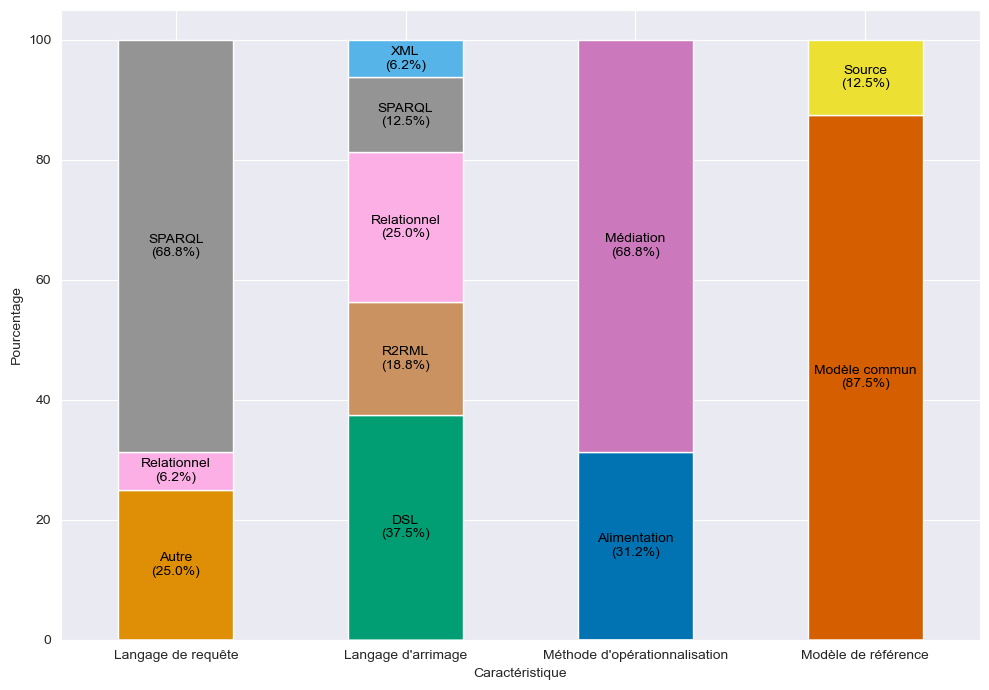

In [5]:
columns_for_histogram = ['Langage de requête', 'Langage d\'arrimage', 'Méthode d\'opérationnalisation', 'Utilisation du modèle commun']
histogram_data = df[columns_for_histogram].copy()

def truncate_and_capitalize(text):
    return re.sub(r'Centré sur (?:(?:le)|(?:la))? (.+)', lambda m: m.group(1).capitalize(), text)

histogram_data['Langage de requête'] = histogram_data['Langage de requête'].replace(to_replace=r'.*Other.*', value='Autre', regex=True)
histogram_data['Utilisation du modèle commun'] = histogram_data['Utilisation du modèle commun'].apply(truncate_and_capitalize)
histogram_data.rename(columns={'Utilisation du modèle commun': 'Modèle de référence'}, inplace=True)
histogram_data_percentage = histogram_data.apply(lambda x: x.value_counts(normalize=True)).T * 100

palette = sns.color_palette("colorblind", n_colors=len(histogram_data_percentage.columns))

ax = histogram_data_percentage.plot(kind='bar', stacked=True, figsize=(10, 7), color=palette, legend=False)

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:  # Ajouter une étiquette uniquement si la hauteur de la barre est positive
            label = f'{container.get_label()}\n({bar.get_height():.1f}%)' 
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                label,
                ha='center',
                va='center',
                color='black'
            )

# plt.title('Caractérisation des méthodes sélectionnées')
plt.xlabel('Caractéristique')
plt.ylabel('Pourcentage')
plt.xticks(rotation=0, ha='center')
plt.tight_layout()

plt.savefig('figures/histogramme.pdf')
plt.show()

## Générer une ligne du temps pour décrire les articles

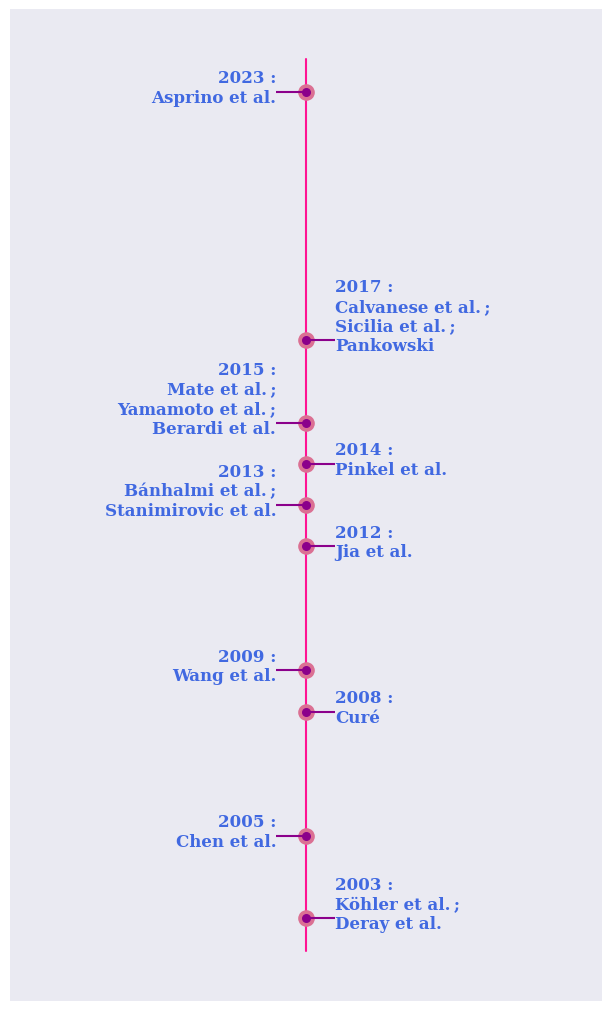

In [ ]:
# Extraire les auteurs et les dates de publication
# Merci à https://dadoverflow.com/2021/08/17/making-timelines-with-python/

entries = bib_database.entries
publications_by_year = {}
years = []
authors = []

def transform_author(author):
    authors_lst = author.split(' and ')
    first_name = re.sub(r'(.+), .+', lambda m: '{0}'.format(m.group(1)), authors_lst[0])

    if len(authors_lst) > 1:
        return f"{first_name} et al."
    else:
        return first_name

for entry in entries:
    if 'author' in entry and 'year' in entry:
        year = int(entry['year'])
        authors_str = transform_author(entry['author'])

        if year not in publications_by_year:
            publications_by_year[year] = []
        publications_by_year[year].append(authors_str)

years = []
authors = []

for year in sorted(publications_by_year.keys()):
    years.append(year)
    authors.append('\u2009;\n'.join(publications_by_year[year]))

min_year = np.min(years) - 2
max_year = np.max(years) + 2

# labels with associated dates
labels = ['{0}\u00A0:\n{1}'.format(d, l) for l, d in zip(authors, years)]
fig, ax = plt.subplots(figsize=(6, 10), constrained_layout=True)
_ = ax.set_xlim(-20, 20)
_ = ax.set_ylim(min_year, max_year)
_ = ax.axvline(0, ymin=0.05, ymax=0.95, c='deeppink', zorder=1)

_ = ax.scatter(np.zeros(len(years)), years, s=120, c='palevioletred', zorder=2)
_ = ax.scatter(np.zeros(len(years)), years, s=30, c='darkmagenta', zorder=3)

label_offsets = np.repeat(2.0, len(years))
label_offsets[1::2] = -2.0
for i, (l, d) in enumerate(zip(labels, years)):
    d = d - 0.25
    align = 'right'
    if i % 2 == 0:
        align = 'left'
    _ = ax.text(label_offsets[i], d, l, ha=align, fontfamily='serif', fontweight='bold', color='royalblue',fontsize=12)

stems = np.repeat(2.0, len(years))
stems[1::2] *= -1.0
x = ax.hlines(years, 0, stems, color='darkmagenta')

# hide lines around chart
for spine in ["left", "top", "right", "bottom"]:
    _ = ax.spines[spine].set_visible(False)

# hide tick labels
_ = ax.set_xticks([])
_ = ax.set_yticks([])

plt.savefig('figures/timeline.pdf')
plt.show()

## Tableau des résultats selon les exigences

In [7]:
columns_for_table = [
    'Study ID',
    'E01 – Indépendance au MCD Oui / Non / NA / ?',
    'E02 – Documentation explicite du procédé Oui / Non / NA / ?',
    'E03 – Documentation des arrimages Oui / Non / NA / ?',
    'E04 – Support de différents SGBD Oui / Non / NA / ?',
    'E05 – Accessibilité du code source Oui / Non / NA / ?',
    'E06 – Support des types de données utilisés dans le modèle de connaissance Oui / Non / NA / ?',
    'E07 – Documentation d’un procédé d’individuation Oui / Non / NA / ?'
]

requirements_data = df[columns_for_table].copy()

# Transformer les réponses: "Oui" -> "X", autres -> ""
def transform_response(value):
    match(str(value).strip().lower()):
        case 'oui':
            return 'X'
        case 'non':
            return '' 
        case '?':
            return '?'
        case _ if pd.isna(value):
            return "n.a."
        case _:
            raise Exception('Value not defined: {0}'.format(value))

for col in requirements_data.columns[1:]:
    requirements_data[col] = requirements_data[col].apply(transform_response)

requirements_data['year'] = requirements_data['Study ID'].apply(get_year)
requirements_data['Study ID'] = requirements_data['Study ID'].apply(transform_ref)

requirements_data.sort_values(by='year', ascending=False, inplace=True)
requirements_data.drop(['year'], axis=1, inplace=True)

requirements_data.columns = [
    'Référence',
    '\cGeneralCKMCode',
    '\cReproductibleCode',
    '\cDocumentCode',
    '\cMultipleDBMSCode',
    '\cOSSCode',
    '\cDPCode',
    '\cIndividuationCode'
]

latex_table = requirements_data.to_latex(index=False)
latex_table = latex_table.replace("\\\n", "\\ \hline\n")
print(latex_table)

\begin{tabular}{llllllll}
\toprule
Référence & \cGeneralCKMCode & \cReproductibleCode & \cDocumentCode & \cMultipleDBMSCode & \cOSSCode & \cDPCode & \cIndividuationCode \\ \hline
\midrule
Asprino et al. \cite{asprino_knowledge_2023} & X &  &  &  &  & X &  \\ \hline
Sicilia et al. \cite{sicilia_map-_2017} & X &  &  & X & X &  &  \\ \hline
Calvanese et al. \cite{calvanese_ontop_2017} & X &  &  & X & X &  &  \\ \hline
Pankowski \cite{pankowski_exploring_2017} & X &  &  &  & X &  &  \\ \hline
Berardi et al. \cite{berardi_r2ba_2015} & X &  & X & ? &  &  &  \\ \hline
Mate et al. \cite{mate_ontology-based_2015} & X &  &  &  &  & X &  \\ \hline
Yamamoto et al. \cite{yamamoto_d2rq_2015} & X &  &  & X & X &  &  \\ \hline
Pinkel et al. \cite{pinkel_how_2014} & X &  &  & n.a. &  &  &  \\ \hline
Bánhalmi et al. \cite{banhalmi_development_2013} & X &  &  & X &  & X &  \\ \hline
Stanimirovic et al. \cite{stanimirovic_methodology_2013} & X &  &  & ? &  &  &  \\ \hline
Jia et al. \cite{jia_smap_2012} &

In [8]:
requirements_data

,Référence,\cGeneralCKMCode,\cReproductibleCode,\cDocumentCode,\cMultipleDBMSCode,\cOSSCode,\cDPCode,\cIndividuationCode
6,Asprino et al. \cite{asprino_knowledge_2023},X,,,,,X,
5,Sicilia et al. \cite{sicilia_map-_2017},X,,,X,X,,
7,Calvanese et al. \cite{calvanese_ontop_2017},X,,,X,X,,
8,Pankowski \cite{pankowski_exploring_2017},X,,,,X,,
1,Berardi et al. \cite{berardi_r2ba_2015},X,,X,?,,,
3,Mate et al. \cite{mate_ontology-based_2015},X,,,,,X,
15,Yamamoto et al. \cite{yamamoto_d2rq_2015},X,,,X,X,,
10,Pinkel et al. \cite{pinkel_how_2014},X,,,n.a.,,,
4,Bánhalmi et al. \cite{banhalmi_development_2013},X,,,X,,X,
11,Stanimirovic et al. \cite{stanimirovic_methodo...,X,,,?,,,


## Générer les paragraphes de résumé
(En ordre décroissant d'année de publication)

In [9]:
columns_for_table = [
    'Study ID',
    'Objectifs de l\'étude',
    'Court résumé'
]

summary_data = df[columns_for_table].copy()

summary_data['year'] = summary_data['Study ID'].apply(get_year)
summary_data.sort_values(by='year', ascending=False, inplace=True)
summary_data.drop(['year'], axis=1, inplace=True)

summary_data['Référence'] = summary_data['Study ID'].apply(transform_ref)
summary_data['BibId'] =  summary_data['Study ID'].apply(lambda covidence_id : id_covidence_to_bib[covidence_id])

def decapitalize(s):
    if not s: 
        return s
    return s[0].lower() + s[1:]

for _, row in summary_data.iterrows():
    print("\\paragraph{{{0}}} L'article vise à {1}. {2}\n".format(row['Référence'], decapitalize(row['Objectifs de l\'étude']),  row['Court résumé']))

\paragraph{Asprino et al. \cite{asprino_knowledge_2023}} L'article vise à donner accès à la source en RDF avant de procéder à l'arrimage. L'article propose une méthode pour accéder à des données relationnelles, CSV, JSON, HTML, etc. à l'aide de SPARQL. Pour ce faire, les auteurs proposent deux étapes: 1) l'utilisation de leur outil SPARQL Anything pour la transformation du modèle original dans un méta-modèle nommé Facade-X de façon à pouvoir 2) permettre l'interrogation des données comme s'il s'agissait de RDF et ainsi pouvoir créer un arrimage vers l'ontologie de référence à l'aide d'expression CONSTRUCT de SPARQL. L'idée étant de découpler les problématiques d'hétérogénéité structurelle et des problématiques d'hétérogénéité sémantique. Le procédé d'extraction est bien explicité, listant ses acteurs et ses artefacts. Cependant, la partie arrimage de celui-ci reste à la discrétion de la personne faisant l'ingénierie de la façade ou de la personne faisant l'ingénierie du graphe de conna

TypeError: 'float' object is not subscriptable